In [1]:
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import spatialdata as sd
from spatialdata_io import xenium
import spatialdata_plot

import matplotlib as mpl
# enables correct plotting of text
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42 

/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


In [2]:
sc.settings.set_figure_params(dpi=80)

In [3]:
figdir = '/rfs/project/rfs-iCNyzSAaucw/kk837/notebooks/Foetal/Revision_Oct2025/fetal_ms_figures'
os.makedirs(figdir,exist_ok=True)

# Read in adata with cell type labels

In [4]:
objects_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/Xenium'
path_adata = f'{objects_dir}/TACCO/tacco-splitted_filtered_celltype-sel_raw.h5ad'
adata = sc.read_h5ad(path_adata,backed='r')
adata

AnnData object with n_obs × n_vars = 239745 × 5001 backed at '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/Xenium/TACCO/tacco-splitted_filtered_celltype-sel_raw.h5ad'
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'n_genes', 'tissue_block_id', 'celltypist_coarse', 'conf_score_coarse', 'celltypist_coarse_fin', 'celltypist_coarse2midmod', 'conf_score_coarse2midmod', 'celltypist_mid_fin', 'celltypist_midmod2fine', 'conf_score_midmod2fine', 'pca_harmony_leiden_0.2', 'pca_harmony_leiden_0.3', 'pca_harmony_leiden_0.4', 'pca_harmony_leiden_0.5'

# Load DAPI image

In [6]:
objects_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/Xenium'

!ls {objects_dir}/zarr

output-XETG00155__0038587__C194-HEA-0-FFPE-1__20241113__134112.zarr
output-XETG00155__0038587__Hst45-HEA-0-FFPE-1__20241113__134112.zarr


In [7]:
sample_id = 'Hst45-HEA-0-FFPE-1'

In [8]:
xenium_path = f'{objects_dir}/zarr/output-XETG00155__0038587__{sample_id}__20241113__134112.zarr'
sdata = sd.read_zarr(xenium_path)
sdata

/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, 

SpatialData object, with associated Zarr store: /rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/Xenium/zarr/output-XETG00155__0038587__Hst45-HEA-0-FFPE-1__20241113__134112.zarr
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 27351, 42633), (4, 13675, 21316), (4, 6837, 10658), (4, 3418, 5329), (4, 1709, 2664)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (27351, 42633), (13675, 21316), (6837, 10658), (3418, 5329), (1709, 2664)
│     └── 'nucleus_labels': DataTree[yx] (27351, 42633), (13675, 21316), (6837, 10658), (3418, 5329), (1709, 2664)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (219198, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (219198, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (218803, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (219198, 5001)
with coordinate systems:
    ▸ 'global', with elements:
        m

In [14]:
sdata.tables["table"].obs['cell_id_2'] = f'{sample_id}_'+sdata.tables["table"].obs['cell_id']
cell_id_order = sdata.tables["table"].obs['cell_id_2'].copy()
sdata.tables["table"].obs['fine_grain_17Apr2026'] = list(adata.obs['fine_grain_17Apr2026'].reindex(cell_id_order))
sdata.tables["table"].obs['fine_grain_17Apr2026'].fillna('nan',inplace=True)
sdata.tables["table"].obs['fine_grain_17Apr2026'].value_counts()

/tmp/ipykernel_2636190/281884003.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sdata.tables["table"].obs['fine_grain_17Apr2026'].fillna('nan',inplace=True)


fine_grain_17Apr2026
nan                                   90005
VentricularCardiomyocytesCycling      36980
VentricularCardiomyocytes             30068
Fibroblasts                           23413
AtrialCardiomyocytesRight             15959
AtrialCardiomyocytesCycling            4965
CoronaryPericytes                      3307
CoronaryVenousEndothelialCells         1825
SchwannCells                           1779
GreatVesselSmoothMuscleCells           1482
AtrialCardiomyocytesLeft               1321
MesothelialEpicardialCells             1284
LymphaticEndothelialCells              1250
MacrophagesLYVE1pos                     878
EndocardialCells                        769
CoronarySmoothMuscleCells               647
CoronaryCapillaryEndothelialCells       584
MacrophagesCX3CR1pos                    480
ParasympatheticNeurons                  379
ArterialEndothelialCells                367
AtrialCardiomyocytesTransitional        328
GreatVesselVenousEndothelialCells       208
Ventricular

INFO     Rasterizing image for faster rendering.                                                                   


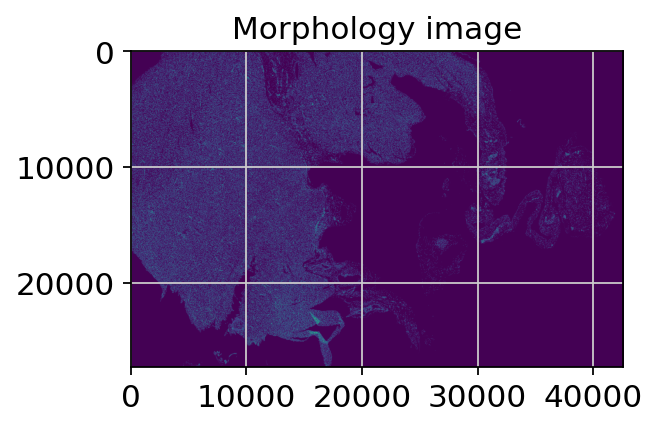

In [9]:
sdata.pl.render_images("morphology_focus", channel="DAPI").pl.show(
    title="Morphology image", coordinate_systems="global", colorbar=False)

In [11]:
%%time
from spatialdata import bounding_box_query
def crop0(x):
    return bounding_box_query(
        x,
        min_coordinate=[27500, 2000],
        max_coordinate=[34000, 15000],
        axes=("x", "y"),
        target_coordinate_system="global",
    )
sdata_cropped = crop0(sdata)

CPU times: user 8min 50s, sys: 1min 20s, total: 10min 11s
Wall time: 2min 4s


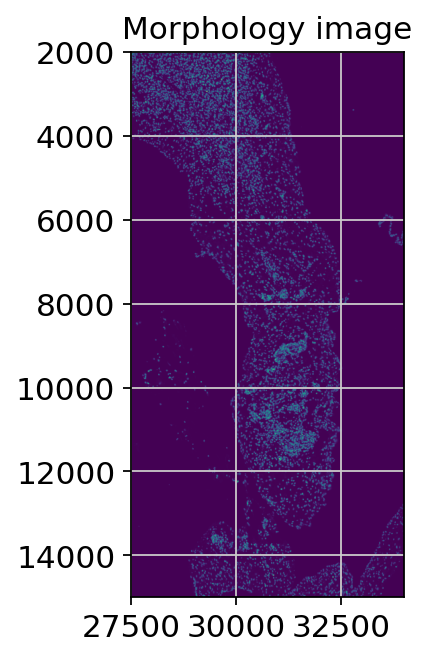

In [12]:
sdata_cropped.pl.render_images("morphology_focus", channel="DAPI").pl.show(
    title="Morphology image", coordinate_systems="global", colorbar=False)

Scale (x, y)
    [4.70588235 4.70588235]
ParasympatheticNeurons 335
SinoatrialNodePacemakerCells 21


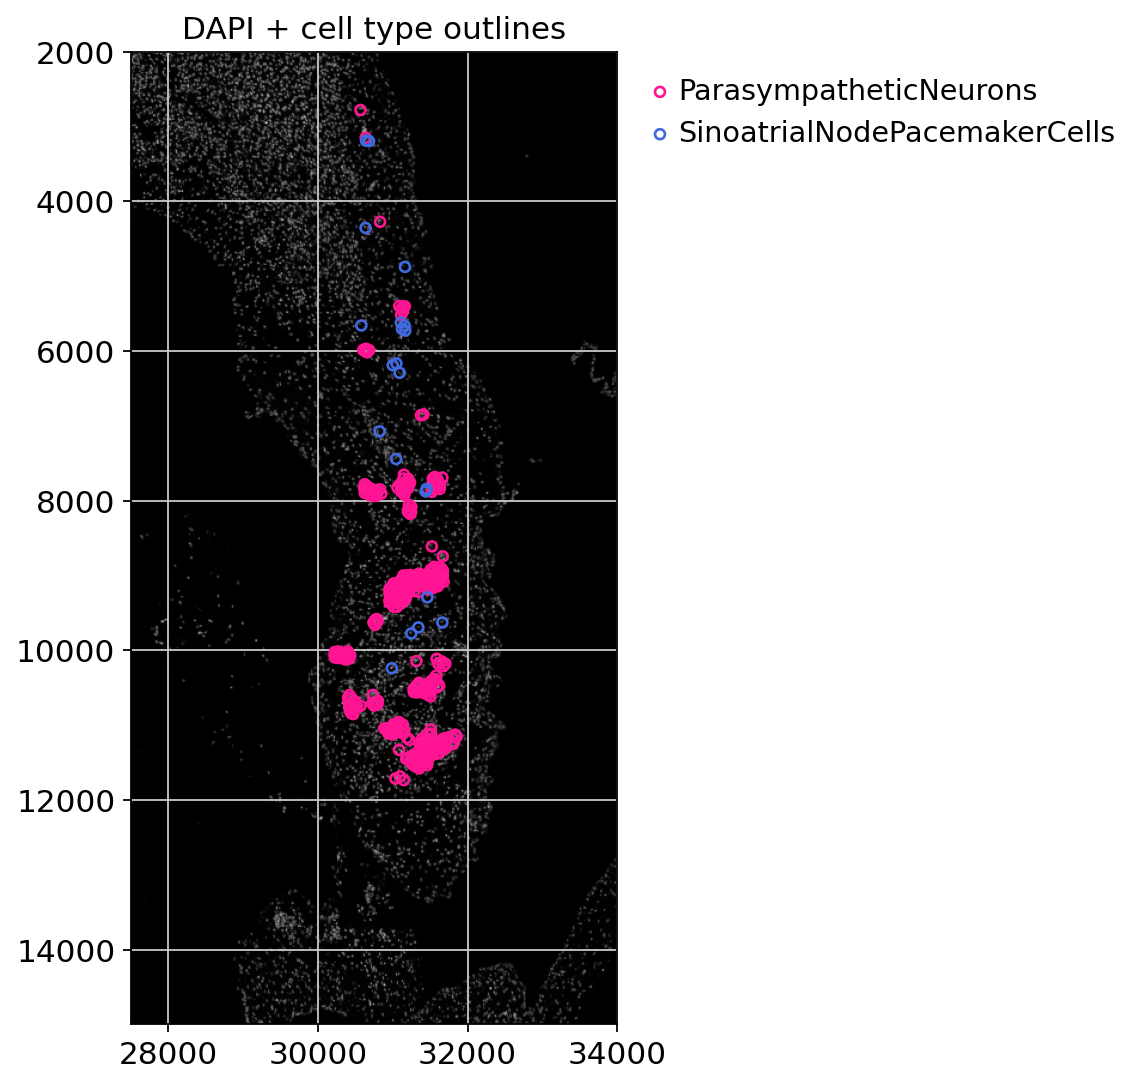

In [28]:
import matplotlib.pyplot as plt
from spatialdata.transformations import get_transformation
from spatialdata import transform

# inspect transform to global
print(get_transformation(sdata_cropped.shapes["cell_circles"], to_coordinate_system="global"))

# transform shapes into the same coordinate system as the rendered image
cell_circles_global = transform(
    sdata_cropped.shapes["cell_circles"],
    to_coordinate_system="global"
)

# keep your annotation mapping from before
# gdf2 was your merged dataframe with fine_grain_17Apr2026 attached
gdf_plot = cell_circles_global.copy()
gdf_plot["fine_grain_17Apr2026"] = sdata_cropped.tables["table"].obs["fine_grain_17Apr2026"].values

cent = gdf_plot.geometry.centroid

palette = {
    "ParasympatheticNeurons": "deeppink",
    "SinoatrialNodePacemakerCells": "royalblue",
}

fig, ax = plt.subplots(figsize=(8, 8))

sdata_cropped.pl.render_images(
    "morphology_focus",
    channel="DAPI",
    cmap="gray"
).pl.show(
    ax=ax,
    coordinate_systems="global",
    colorbar=False,
    title="DAPI + cell type outlines"
)

for ct, color in palette.items():
    mask = gdf_plot["fine_grain_17Apr2026"] == ct
    print(ct, mask.sum())
    if mask.sum() == 0:
        continue

    ax.scatter(
        cent.x[mask],
        cent.y[mask],
        s=20,
        facecolors="none",
        edgecolors=color,
        linewidths=1.2,
        label=ct,
        zorder=10,
    )

# ax.grid(False)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
# plt.savefig(f'{figdir}/Xenium5K_SAN-zoom-in_DAPI-SANPC-ParaN_C194-HEA-0-FFPE-1.pdf',
#                 bbox_inches="tight",dpi=300)
plt.show()

In [34]:
from spatialdata import bounding_box_query
def crop0(x):
    return bounding_box_query(
        x,
        min_coordinate=[31000, 5300],
        max_coordinate=[31300, 5900],
        axes=("x", "y"),
        target_coordinate_system="global",
    )
sdata_cropped3 = crop0(sdata)

/home/kk837/.conda/envs/generic_env/lib/python3.10/functools.py:889: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


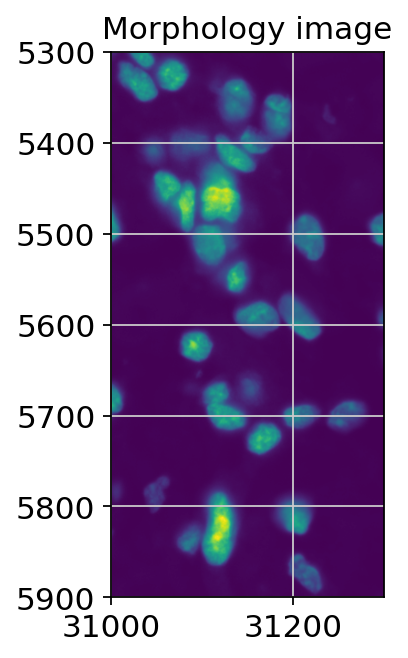

In [35]:
sdata_cropped3.pl.render_images("morphology_focus", channel="DAPI").pl.show(
    title="Morphology image", coordinate_systems="global", colorbar=False)

Scale (x, y)
    [4.70588235 4.70588235]
ParasympatheticNeurons 6
SinoatrialNodePacemakerCells 4


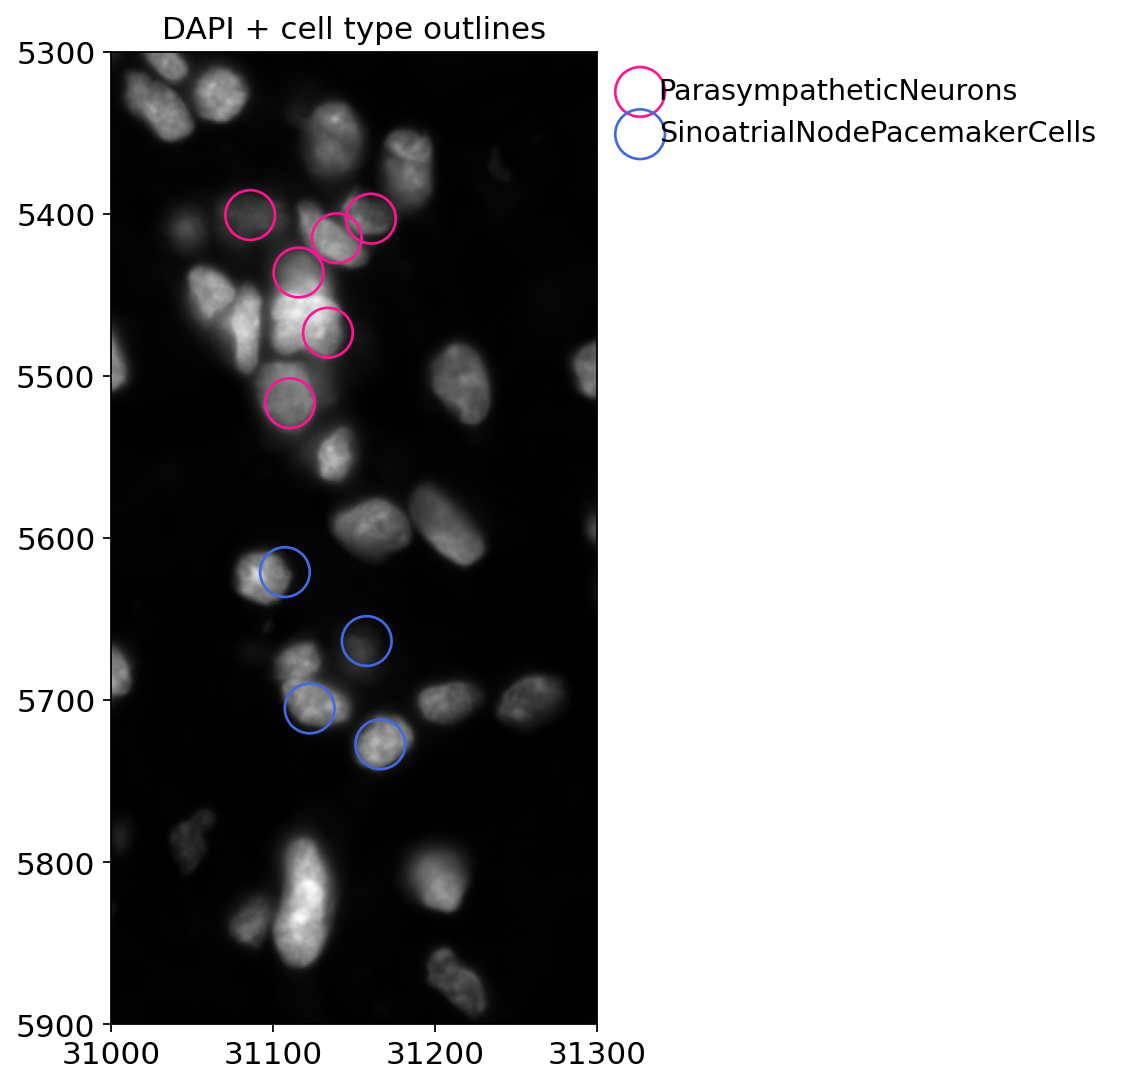

In [43]:
import matplotlib.pyplot as plt
from spatialdata.transformations import get_transformation
from spatialdata import transform

# inspect transform to global
print(get_transformation(sdata_cropped3.shapes["cell_circles"], to_coordinate_system="global"))

# transform shapes into the same coordinate system as the rendered image
cell_circles_global = transform(
    sdata_cropped3.shapes["cell_circles"],
    to_coordinate_system="global"
)

# keep your annotation mapping from before
# gdf2 was your merged dataframe with fine_grain_17Apr2026 attached
gdf_plot = cell_circles_global.copy()
gdf_plot["fine_grain_17Apr2026"] = sdata_cropped3.tables["table"].obs["fine_grain_17Apr2026"].values

cent = gdf_plot.geometry.centroid

palette = {
    "ParasympatheticNeurons": "deeppink",
    "SinoatrialNodePacemakerCells": "royalblue",
}

fig, ax = plt.subplots(figsize=(8, 8))

sdata_cropped3.pl.render_images(
    "morphology_focus",
    channel="DAPI",
    cmap="gray"
).pl.show(
    ax=ax,
    coordinate_systems="global",
    colorbar=False,
    title="DAPI + cell type outlines"
)

for ct, color in palette.items():
    mask = gdf_plot["fine_grain_17Apr2026"] == ct
    print(ct, mask.sum())
    if mask.sum() == 0:
        continue

    ax.scatter(
        cent.x[mask],
        cent.y[mask],
        s=500,
        facecolors="none",
        edgecolors=color,
        linewidths=1.2,
        label=ct,
        zorder=10,
    )

ax.grid(False)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.savefig(f'{figdir}/Xenium5K_SAN-zoom-in-1_DAPI-SANPC-ParaN_{sample_id}.pdf',
            bbox_inches="tight",dpi=300)
plt.show()

In [37]:
from spatialdata import bounding_box_query
def crop0(x):
    return bounding_box_query(
        x,
        min_coordinate=[30900, 8900],
        max_coordinate=[31800, 10000],
        axes=("x", "y"),
        target_coordinate_system="global",
    )
sdata_cropped2 = crop0(sdata)

/home/kk837/.conda/envs/generic_env/lib/python3.10/functools.py:889: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


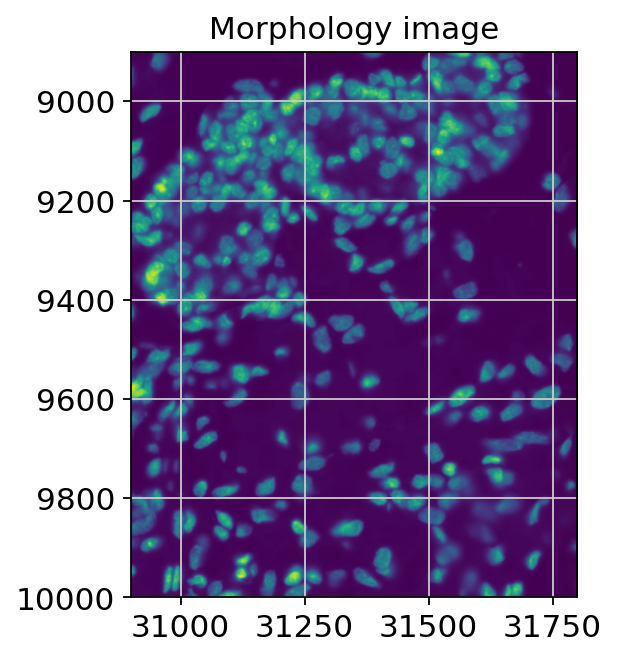

In [38]:
sdata_cropped2.pl.render_images("morphology_focus", channel="DAPI").pl.show(
    title="Morphology image", coordinate_systems="global", colorbar=False)

In [39]:
import matplotlib.pyplot as plt
import pandas as pd
from spatialdata import SpatialData

gdf = sdata_cropped2.shapes["cell_circles"].copy()
table = sdata_cropped2.tables["table"]

# SpatialData metadata
region_col = SpatialData.get_region_key_column(table).name
instance_col = SpatialData.get_instance_key_column(table).name

print("region_col:", region_col)
print("instance_col:", instance_col)
print(table.obs[region_col].value_counts(dropna=False))

# keep only rows annotating the cell_circles element
obs_cc = table.obs.loc[table.obs[region_col] == "cell_circles"].copy()

# build mapping from shape index -> annotation
annot_col = "fine_grain_17Apr2026"

# IMPORTANT: shape index and instance_key must have same dtype for merging
gdf2 = gdf.copy()
gdf2["_shape_id"] = gdf2.index.astype(str)

obs_cc["_shape_id"] = obs_cc[instance_col].astype(str)

gdf2 = gdf2.merge(
    obs_cc[["_shape_id", annot_col]],
    on="_shape_id",
    how="left"
)

print(gdf2[annot_col].isna().mean())
print(gdf2[annot_col].value_counts(dropna=False).head())

region_col: region
instance_col: cell_id
region
cell_circles    341
Name: count, dtype: int64
0.0
fine_grain_17Apr2026
ParasympatheticNeurons            97
nan                               95
Fibroblasts                       92
SchwannCells                      14
CoronaryVenousEndothelialCells    12
Name: count, dtype: int64


Scale (x, y)
    [4.70588235 4.70588235]
ParasympatheticNeurons 97
SinoatrialNodePacemakerCells 4


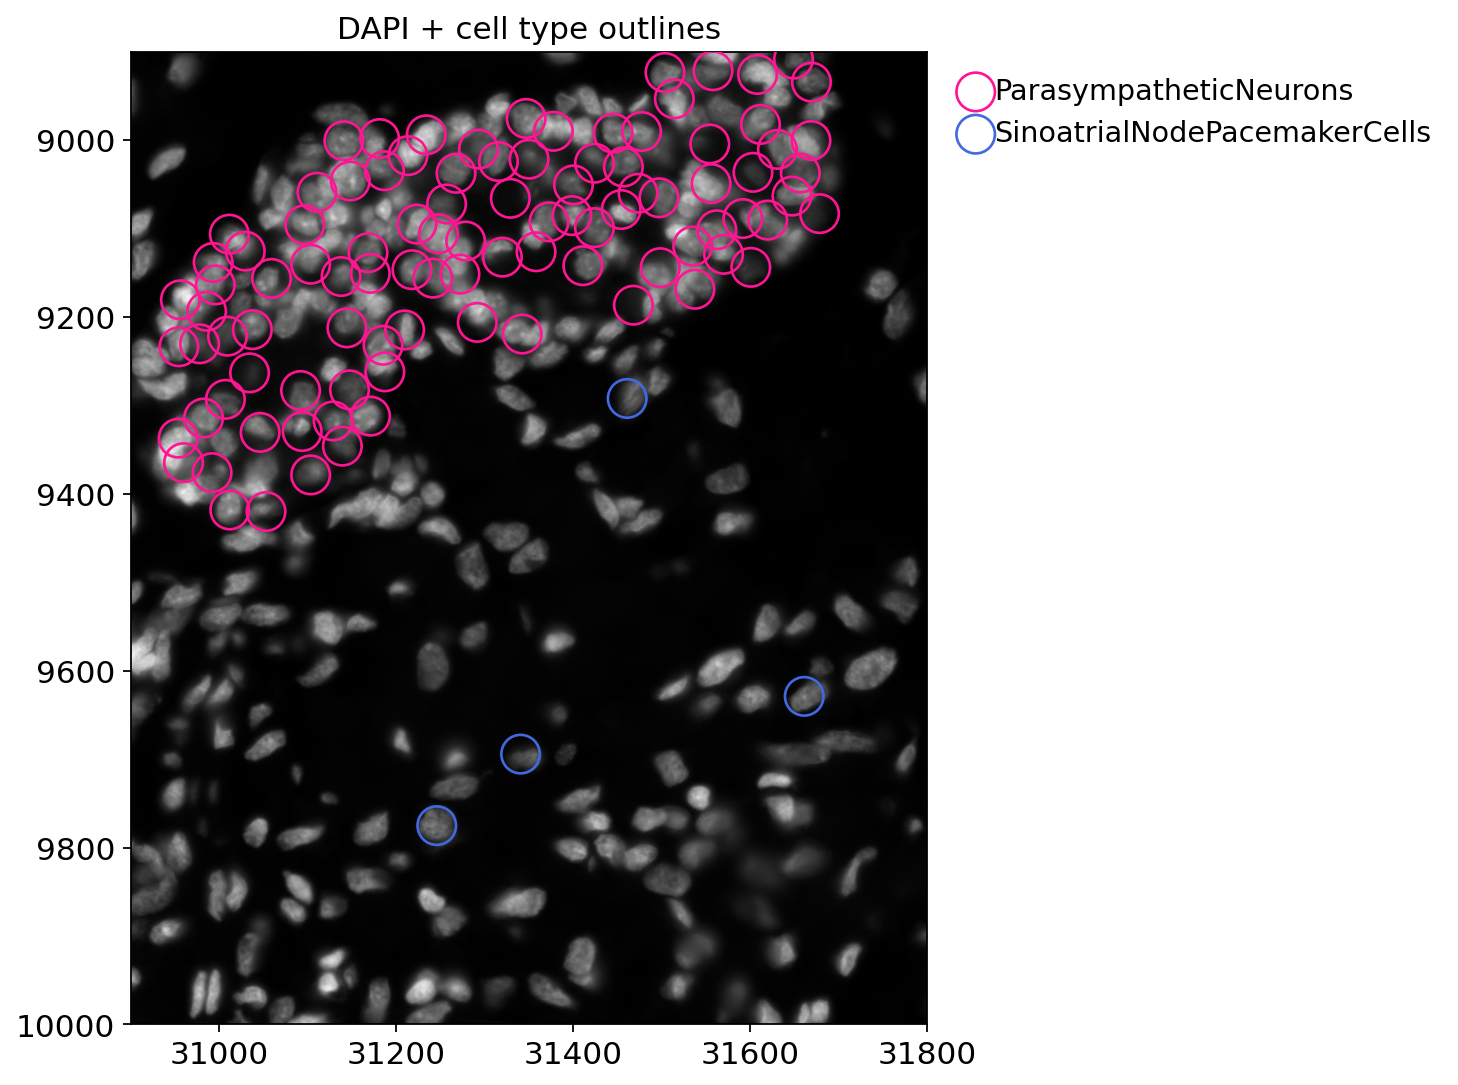

In [44]:
import matplotlib.pyplot as plt
from spatialdata.transformations import get_transformation
from spatialdata import transform

# inspect transform to global
print(get_transformation(sdata_cropped2.shapes["cell_circles"], to_coordinate_system="global"))

# transform shapes into the same coordinate system as the rendered image
cell_circles_global = transform(
    sdata_cropped2.shapes["cell_circles"],
    to_coordinate_system="global"
)

# keep your annotation mapping from before
# gdf2 was your merged dataframe with fine_grain_17Apr2026 attached
gdf_plot = cell_circles_global.copy()
gdf_plot["fine_grain_17Apr2026"] = sdata_cropped2.tables["table"].obs["fine_grain_17Apr2026"].values

cent = gdf_plot.geometry.centroid

palette = {
    "ParasympatheticNeurons": "deeppink",
    "SinoatrialNodePacemakerCells": "royalblue",
}

fig, ax = plt.subplots(figsize=(8, 8))

sdata_cropped2.pl.render_images(
    "morphology_focus",
    channel="DAPI",
    cmap="gray"
).pl.show(
    ax=ax,
    coordinate_systems="global",
    colorbar=False,
    title="DAPI + cell type outlines"
)

for ct, color in palette.items():
    mask = gdf_plot["fine_grain_17Apr2026"] == ct
    print(ct, mask.sum())
    if mask.sum() == 0:
        continue

    ax.scatter(
        cent.x[mask],
        cent.y[mask],
        s=300,
        facecolors="none",
        edgecolors=color,
        linewidths=1.2,
        label=ct,
        zorder=10,
    )

ax.grid(False)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.savefig(f'{figdir}/Xenium5K_SAN-zoom-in-2_DAPI-SANPC-ParaN_{sample_id}.pdf',
            bbox_inches="tight",dpi=300)
plt.show()